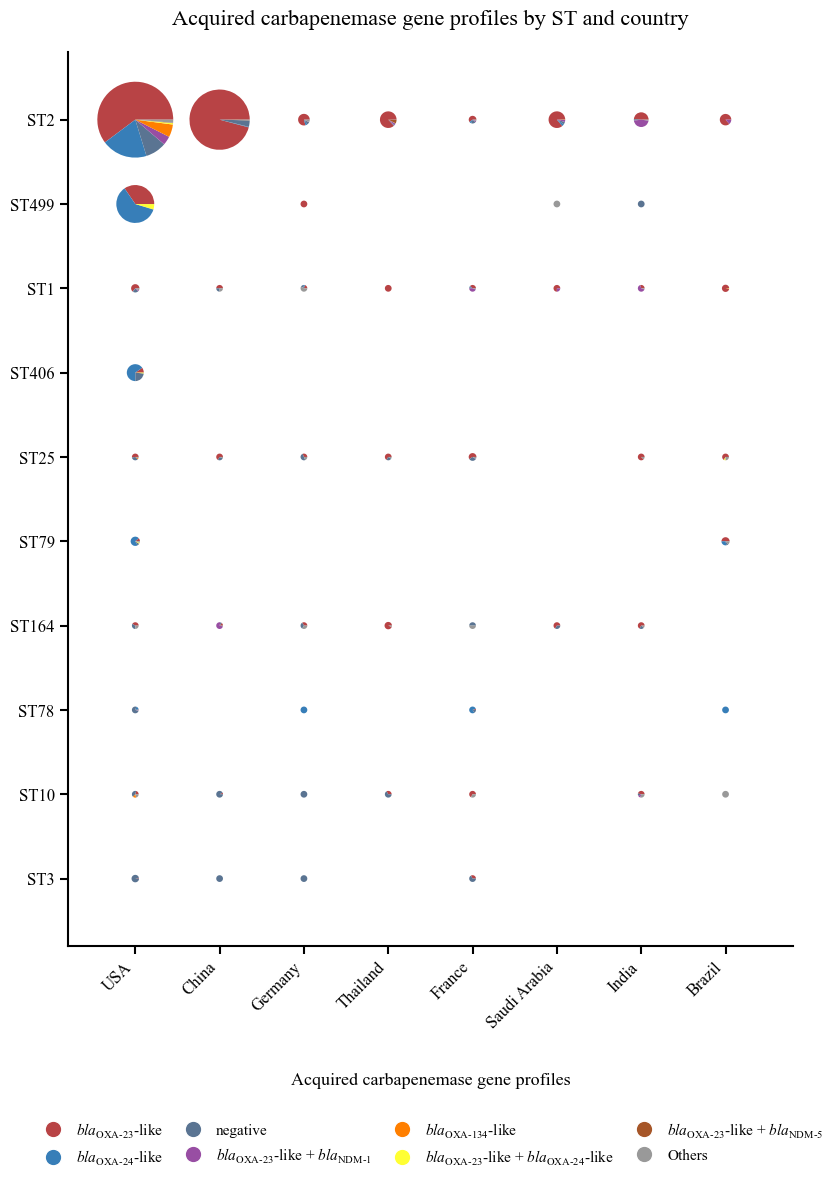

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 0. 全局字体设置
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# ================= 新增核心配置 =================
# 强制数学公式（图例中的斜体和下标）也使用不加粗的 Times New Roman
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'         # 正体使用常规新罗马
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'  # 斜体使用常规新罗马斜体
# ================================================

# ==========================================
# 1. 数据读取与多重筛选
# ==========================================
meta_df = pd.read_csv(r'D:\A.baumannii\data\antibiotic_classes_matched_metadata.csv')
geno_df = pd.read_csv(r'D:\A.baumannii\data\carbapenem_matched_representatives.csv')

# 1.1 筛选 ST: 剔除 '-', 取前 10
valid_st = meta_df[(meta_df['ST'].notna()) & (meta_df['ST'].astype(str).str.strip() != '-')]
top10_st = valid_st['ST'].value_counts().nlargest(10).index.tolist()

# 1.2 筛选 Country: 剔除 'others', 取前 8
valid_country = meta_df[(meta_df['country'].notna()) & (meta_df['country'].astype(str).str.lower() != 'others')]
top8_country = valid_country['country'].value_counts().nlargest(8).index.tolist()

# 1.3 合并数据表
merged_df = pd.merge(meta_df[['Genome_ID', 'ST', 'country']], 
                     geno_df[['Genome_ID', 'Genotype']], 
                     on='Genome_ID', how='inner')

# 1.4 根据 Top 10 ST 和 Top 8 Country 截取子集
plot_df = merged_df[(merged_df['ST'].isin(top10_st)) & (merged_df['country'].isin(top8_country))].copy()

# 1.5 筛选 Genotype: 取子集中数量最多的前 7 种，剩下的归为 'Others'
top7_geno = plot_df['Genotype'].value_counts().nlargest(7).index.tolist()
plot_df['Plot_Label'] = plot_df['Genotype'].apply(lambda x: x if x in top7_geno else 'Others')

# 提取用于画图的所有分类名称
categories = top7_geno + ['Others'] if 'Others' not in top7_geno else top7_geno

# ==========================================
# 2. 数据透视与坐标映射
# ==========================================
grouped = plot_df.groupby(['country', 'ST', 'Plot_Label']).size().unstack(fill_value=0)
grouped['Total'] = grouped.sum(axis=1)
max_total = grouped['Total'].max()  

st_y_mapping = {st: i for i, st in enumerate(reversed(top10_st))}
country_x_mapping = {country: i for i, country in enumerate(top8_country)}

# ==========================================
# 3. 颜色精准配置
# ==========================================
color_palette = ["#B84345", "#377EB8", "#5A7492", "#984EA3", "#FF7F00", "#FFFF33", "#A65628"]
color_dict = {}
c_idx = 0
for cat in categories:
    if cat == 'Negative':
        color_dict[cat] = '#E0E0E0'  
    elif cat == 'Others':
        color_dict[cat] = '#999999'  
    else:
        color_dict[cat] = color_palette[c_idx % len(color_palette)]
        c_idx += 1

# ==========================================
# 4. 绘制气泡饼图 
# ==========================================
fig, ax = plt.subplots(figsize=(10, 12))

base_radius = 0.45  

for (country, st), row in grouped.iterrows():
    total_count = row['Total']
    if total_count == 0:
        continue
        
    x = country_x_mapping[country]
    y = st_y_mapping[st]
    
    r = base_radius * np.sqrt(total_count / max_total)
    if r < 0.04:
        r = 0.04
    
    theta1 = 0
    for cat in categories:
        count = row.get(cat, 0)
        if count == 0:
            continue
        theta2 = theta1 + 360 * (count / total_count)
        wedge = Wedge(center=(x, y), r=r, theta1=theta1, theta2=theta2, 
                      facecolor=color_dict[cat], edgecolor='none')
        ax.add_patch(wedge)
        theta1 = theta2

# ==========================================
# 5. 坐标轴、刻度与边框美化
# ==========================================
ax.set_aspect('equal') 

ax.set_xticks(range(len(top8_country)))
ax.set_xticklabels(top8_country, rotation=45, ha='right', fontsize=12)
ax.set_xlim(-0.8, len(top8_country) - 0.2)

yticklabels = [f"ST{st}" if not str(st).upper().startswith('ST') else str(st) for st in reversed(top10_st)]
ax.set_yticks(range(len(top10_st)))
ax.set_yticklabels(yticklabels, fontsize=12)
ax.set_ylim(-0.8, len(top10_st) - 0.2)

ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6, direction='out',
               bottom=True, left=True, top=False, right=False)

# ==========================================
# 6. 生成高级圆点图例与标题 (修复横杠与字体)
# ==========================================
ax.set_title('Acquired carbapenemase gene profiles by ST and country', fontsize=16, pad=20)

def format_genotype(name):
    if name in ['Negative', 'Others']:
        return name
        
    parts = name.split(' + ')
    formatted_parts = []
    
    for p in parts:
        if p.startswith('blaOXA-') or p.startswith('blaNDM-'):
            # 提取基因后缀（如 OXA-23）
            gene_suffix = p.replace('bla', '')
            # 使用标准的 \mathrm 和 \text{-} 完美兼容短横杠与 Times New Roman 正体
            suffix_math = gene_suffix.replace('-', r'}\text{-}\mathrm{')
            
            if p.startswith('blaOXA-'):
                formatted = rf'$\mathit{{bla}}_{{\mathrm{{{suffix_math}}}}}$' + '-like'
            else:
                formatted = rf'$\mathit{{bla}}_{{\mathrm{{{suffix_math}}}}}$'
            formatted_parts.append(formatted)
        else:
            formatted_parts.append(p)
            
    return ' + '.join(formatted_parts)

legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[cat], 
                          markersize=12, label=format_genotype(cat)) for cat in categories]

ax.text(0.5, -0.15, "Acquired carbapenemase gene profiles", ha='center', va='center', 
        transform=ax.transAxes, fontsize=13)

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.18), 
          ncol=4, frameon=False, fontsize=11, handletextpad=0.5, columnspacing=1.0)

plt.tight_layout()

# 保存高清图片
plt.savefig('ST and country.png', dpi=600, bbox_inches='tight')
plt.show()


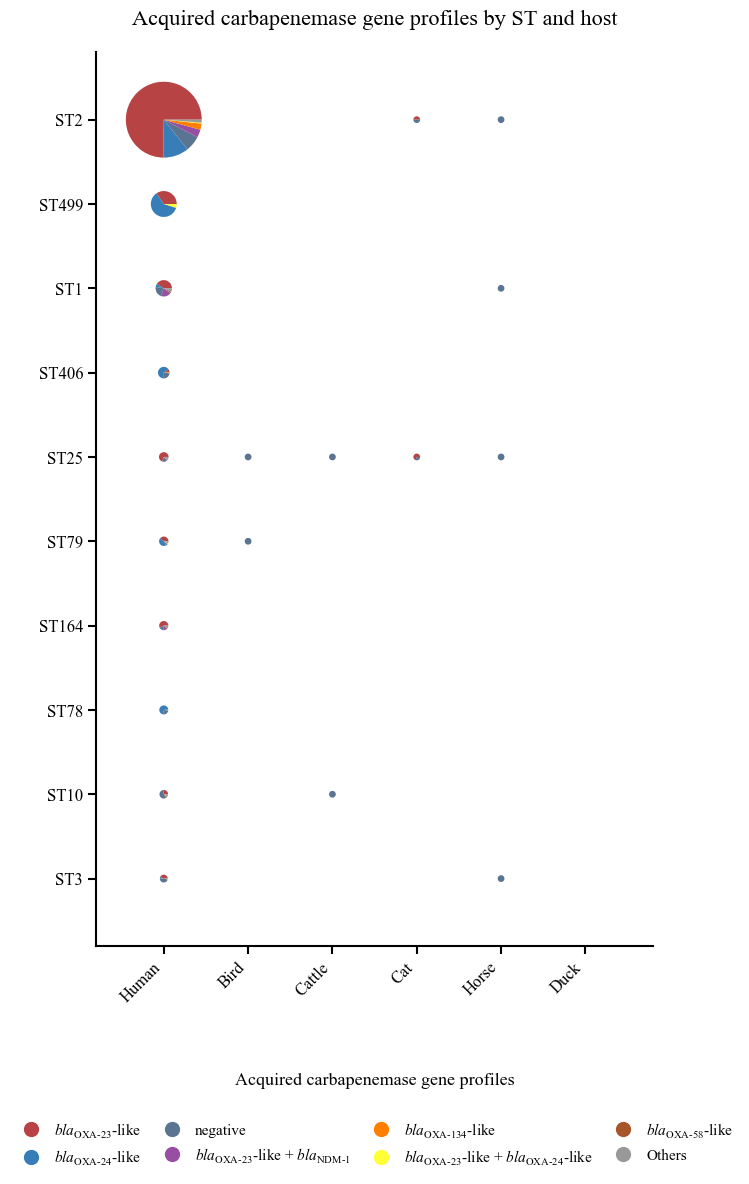

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 0. 全局字体设置
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# ================= 新增核心配置 =================
# 强制数学公式（图例中的斜体和下标）也使用不加粗的 Times New Roman
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'         # 正体使用常规新罗马
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'  # 斜体使用常规新罗马斜体
# ================================================

# ==========================================
# 1. 数据读取与多重筛选
# ==========================================
meta_df = pd.read_csv(r'D:\A.baumannii\data\antibiotic_classes_matched_metadata.csv')
geno_df = pd.read_csv(r'D:\A.baumannii\data\carbapenem_matched_representatives.csv')


# 1.1 筛选 ST: 剔除 '-', 取前 10
valid_st = meta_df[(meta_df['ST'].notna()) & (meta_df['ST'].astype(str).str.strip() != '-')]
top10_st = valid_st['ST'].value_counts().nlargest(10).index.tolist()

# 1.2 筛选 Host: 剔除 'others' (忽略大小写), 取前 6 种宿主
valid_host = meta_df[(meta_df['Host'].notna()) & (meta_df['Host'].astype(str).str.lower() != 'others')]
top6_host = valid_host['Host'].value_counts().nlargest(6).index.tolist()

# 1.3 合并数据表 (将 country 替换为 Host)
merged_df = pd.merge(meta_df[['Genome_ID', 'ST', 'Host']], 
                     geno_df[['Genome_ID', 'Genotype']], 
                     on='Genome_ID', how='inner')

# 1.4 根据 Top 10 ST 和 Top 6 Host 截取子集
plot_df = merged_df[(merged_df['ST'].isin(top10_st)) & (merged_df['Host'].isin(top6_host))].copy()

# 1.5 筛选 Genotype: 取子集中数量最多的前 7 种，剩下的归为 'Others'
top7_geno = plot_df['Genotype'].value_counts().nlargest(7).index.tolist()
plot_df['Plot_Label'] = plot_df['Genotype'].apply(lambda x: x if x in top7_geno else 'Others')

# 提取用于画图的所有分类名称（确保 Others 排在最后）
categories = top7_geno + ['Others'] if 'Others' not in top7_geno else top7_geno

# ==========================================
# 2. 数据透视与坐标映射
# ==========================================
# 按照 Host, ST 分组统计
grouped = plot_df.groupby(['Host', 'ST', 'Plot_Label']).size().unstack(fill_value=0)
grouped['Total'] = grouped.sum(axis=1)
max_total = grouped['Total'].max()  # 最大样本量，用于计算气泡半径

# 让数量最多的 ST 显示在 Y 轴最上方
st_y_mapping = {st: i for i, st in enumerate(reversed(top10_st))}
# 映射 X 轴的宿主
host_x_mapping = {host: i for i, host in enumerate(top6_host)}

# ==========================================
# 3. 颜色精准配置
# ==========================================
color_palette = ["#B84345", "#377EB8", "#5A7492", "#984EA3", "#FF7F00", "#FFFF33", "#A65628"]
color_dict = {}
c_idx = 0
for cat in categories:
    if cat == 'Negative':
        color_dict[cat] = '#E0E0E0'  # 浅灰色
    elif cat == 'Others':
        color_dict[cat] = '#999999'  # 深灰色
    else:
        color_dict[cat] = color_palette[c_idx % len(color_palette)]
        c_idx += 1

# ==========================================
# 4. 使用底层 Wedge 绘制气泡饼图 
# ==========================================
# 调整了一下宽度，因为 6个Host 比 8个国家稍微窄一点，figsize=(9, 12) 比例更好看
fig, ax = plt.subplots(figsize=(9, 12))

base_radius = 0.45  # 保证气泡绝对不会互相重叠

for (host, st), row in grouped.iterrows():
    total_count = row['Total']
    if total_count == 0:
        continue
        
    x = host_x_mapping[host]
    y = st_y_mapping[st]
    
    # 半径正比于 开根号(该气泡样本量 / 最大样本量)
    r = base_radius * np.sqrt(total_count / max_total)
    
    if r < 0.04:
        r = 0.04
    
    # 绘制气泡内的颜色切片
    theta1 = 0
    for cat in categories:
        count = row.get(cat, 0)
        if count == 0:
            continue
        theta2 = theta1 + 360 * (count / total_count)
        wedge = Wedge(center=(x, y), r=r, theta1=theta1, theta2=theta2, 
                      facecolor=color_dict[cat], edgecolor='none')
        ax.add_patch(wedge)
        theta1 = theta2

# ==========================================
# 5. 坐标轴、刻度与边框美化
# ==========================================
ax.set_aspect('equal') 

# X 轴设置 (将宿主名称首字母大写，如 human -> Human)
host_labels_capitalized = [str(h).capitalize() for h in top6_host]
ax.set_xticks(range(len(top6_host)))
ax.set_xticklabels(host_labels_capitalized, rotation=45, ha='right', fontsize=12)
ax.set_xlim(-0.8, len(top6_host) - 0.2)

# Y 轴设置
yticklabels = [f"ST{st}" if not str(st).upper().startswith('ST') else str(st) for st in reversed(top10_st)]
ax.set_yticks(range(len(top10_st)))
ax.set_yticklabels(yticklabels, fontsize=12)
ax.set_ylim(-0.8, len(top10_st) - 0.2)

# 边框与刻度线处理 (L型)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6, direction='out',
               bottom=True, left=True, top=False, right=False)

# ==========================================
# 6. 生成高级圆点图例与标题 (完美兼容新罗马与短横杠)
# ==========================================
ax.set_title('Acquired carbapenemase gene profiles by ST and host', fontsize=16, pad=20)

def format_genotype(name):
    if name in ['Negative', 'Others']:
        return name
        
    parts = name.split(' + ')
    formatted_parts = []
    
    for p in parts:
        if p.startswith('blaOXA-') or p.startswith('blaNDM-'):
            # 提取基因后缀（如 OXA-23）
            gene_suffix = p.replace('bla', '')
            # 使用标准的 \mathrm 和 \text{-} 完美兼容短横杠与 Times New Roman 正体
            suffix_math = gene_suffix.replace('-', r'}\text{-}\mathrm{')
            
            if p.startswith('blaOXA-'):
                formatted = rf'$\mathit{{bla}}_{{\mathrm{{{suffix_math}}}}}$' + '-like'
            else:
                formatted = rf'$\mathit{{bla}}_{{\mathrm{{{suffix_math}}}}}$'
            formatted_parts.append(formatted)
        else:
            formatted_parts.append(p)
            
    return ' + '.join(formatted_parts)

legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[cat], 
                          markersize=12, label=format_genotype(cat)) for cat in categories]

ax.text(0.5, -0.15, "Acquired carbapenemase gene profiles", ha='center', va='center', 
        transform=ax.transAxes, fontsize=13)

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.18), 
          ncol=4, frameon=False, fontsize=11, handletextpad=0.5, columnspacing=1.0)

plt.tight_layout()

# 另存为 Host 版的图片，防覆盖
plt.savefig('ST and host.png', dpi=600, bbox_inches='tight')
plt.show()


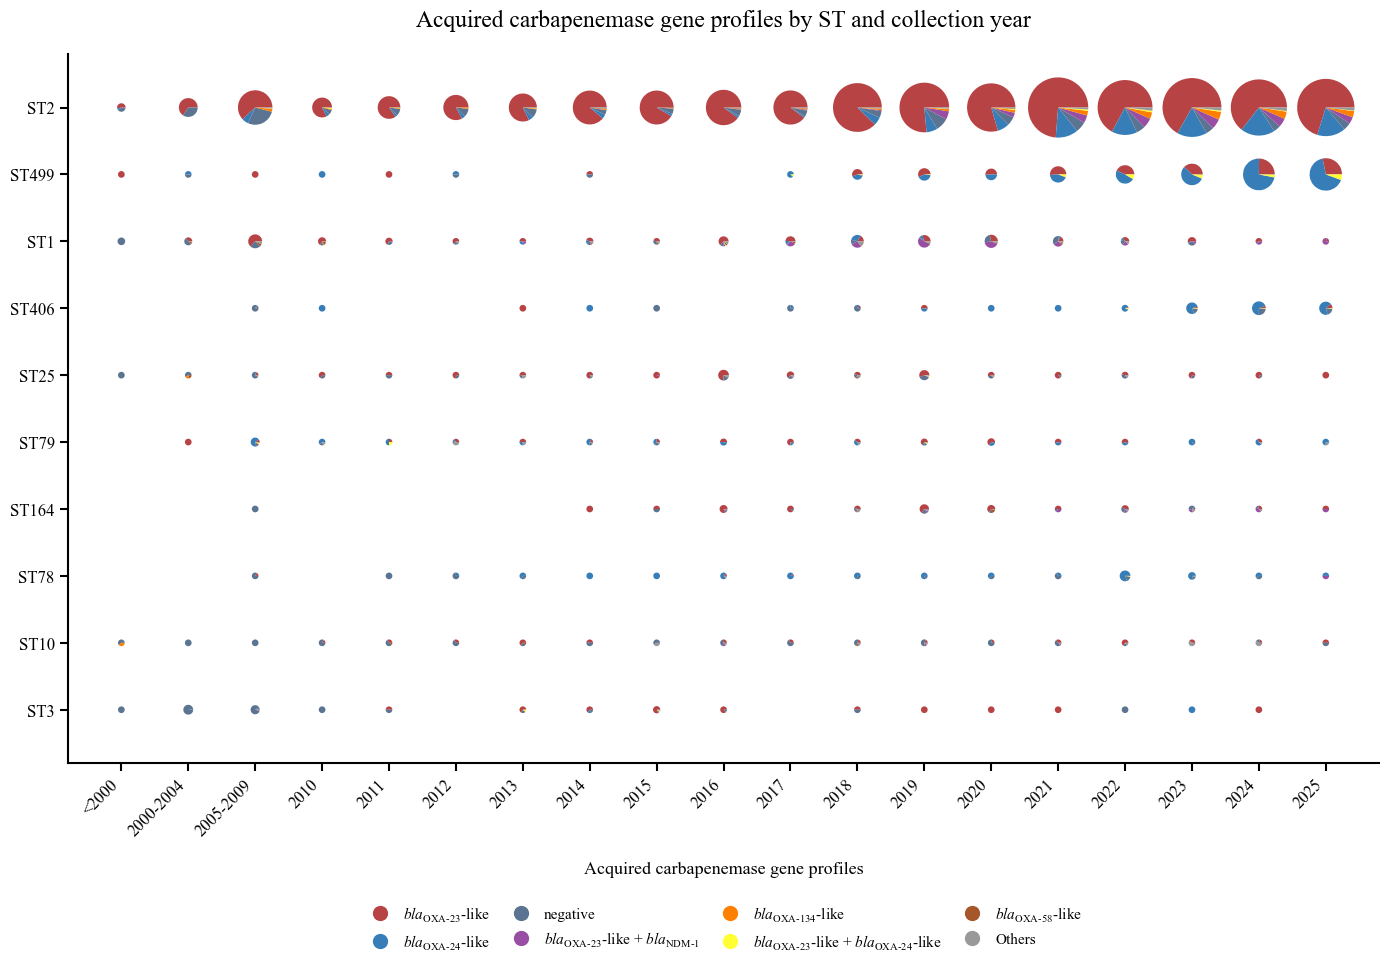

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 0. 全局字体设置
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# ================= 新增核心配置 =================
# 强制数学公式（图例中的斜体和下标）也使用不加粗的 Times New Roman
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'         # 正体使用常规新罗马
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'  # 斜体使用常规新罗马斜体
# ================================================

# ==========================================
# 1. 数据读取与时间分箱 (Binning)
# ==========================================
meta_df = pd.read_csv(r'D:\A.baumannii\data\antibiotic_classes_matched_metadata.csv')
geno_df = pd.read_csv(r'D:\A.baumannii\data\carbapenem_matched_representatives.csv')

# 1.1 筛选 ST: 剔除 '-', 取前 10
valid_st = meta_df[(meta_df['ST'].notna()) & (meta_df['ST'].astype(str).str.strip() != '-')]
top10_st = valid_st['ST'].value_counts().nlargest(10).index.tolist()

# 1.2 处理 Year 列：定义时间分组逻辑
def assign_year_bin(y):
    try:
        y = int(float(y)) # 将可能是字符串的年份转为整数
    except:
        return np.nan # 过滤掉非数字的异常值
        
    if y < 2000:
        return '<2000'
    elif 2000 <= y <= 2004:
        return '2000-2004'
    elif 2005 <= y <= 2009:
        return '2005-2009'
    elif 2010 <= y <= 2025:
        return str(y)
    else:
        return np.nan # 剔除 2025 年以后的异常数据

# 应用年份分组函数，生成新的一列 'year_bin'
meta_df['year_bin'] = meta_df['year'].apply(assign_year_bin)

# 定义严格的横轴显示顺序 (一共 19 个时间节点)
year_bins_order = ['<2000', '2000-2004', '2005-2009'] + [str(y) for y in range(2010, 2026)]

# 1.3 合并数据表
merged_df = pd.merge(meta_df[['Genome_ID', 'ST', 'year_bin']], 
                     geno_df[['Genome_ID', 'Genotype']], 
                     on='Genome_ID', how='inner')

# 1.4 根据 Top 10 ST 和 有效年份区间截取子集
plot_df = merged_df[(merged_df['ST'].isin(top10_st)) & (merged_df['year_bin'].notna())].copy()

# 1.5 筛选 Genotype: 取子集中数量最多的前 7 种，剩下的归为 'Others'
top7_geno = plot_df['Genotype'].value_counts().nlargest(7).index.tolist()
plot_df['Plot_Label'] = plot_df['Genotype'].apply(lambda x: x if x in top7_geno else 'Others')

# 提取用于画图的所有分类名称
categories = top7_geno + ['Others'] if 'Others' not in top7_geno else top7_geno

# ==========================================
# 2. 数据透视与坐标映射
# ==========================================
# 将 country 替换为 year_bin 进行透视
grouped = plot_df.groupby(['year_bin', 'ST', 'Plot_Label']).size().unstack(fill_value=0)
grouped['Total'] = grouped.sum(axis=1)
max_total = grouped['Total'].max()  

# 映射 Y 轴：ST 数量最多在最上
st_y_mapping = {st: i for i, st in enumerate(reversed(top10_st))}
# 映射 X 轴：严格按时间顺序排列
year_x_mapping = {y_bin: i for i, y_bin in enumerate(year_bins_order)}

# ==========================================
# 3. 颜色精准配置
# ==========================================
color_palette = ["#B84345", "#377EB8", "#5A7492", "#984EA3", "#FF7F00", "#FFFF33", "#A65628"]
color_dict = {}
c_idx = 0
for cat in categories:
    if cat == 'Negative':
        color_dict[cat] = '#E0E0E0'  
    elif cat == 'Others':
        color_dict[cat] = '#999999'  
    else:
        color_dict[cat] = color_palette[c_idx % len(color_palette)]
        c_idx += 1

# ==========================================
# 4. 绘制气泡饼图 (适应超宽横坐标)
# ==========================================
# 因为有19个横轴节点，把画布宽度调宽到 15，高度 9，防止气泡过分拥挤
fig, ax = plt.subplots(figsize=(15, 9))

base_radius = 0.45  # 控制最大半径

for (y_bin, st), row in grouped.iterrows():
    total_count = row['Total']
    if total_count == 0:
        continue
        
    x = year_x_mapping[y_bin]
    y = st_y_mapping[st]
    
    # 半径正比于 开根号(当前样本量/最大样本量)
    r = base_radius * np.sqrt(total_count / max_total)
    if r < 0.05:  # 让数量极少的气泡也能被勉强看到
        r = 0.05
    
    theta1 = 0
    for cat in categories:
        count = row.get(cat, 0)
        if count == 0:
            continue
        theta2 = theta1 + 360 * (count / total_count)
        wedge = Wedge(center=(x, y), r=r, theta1=theta1, theta2=theta2, 
                      facecolor=color_dict[cat], edgecolor='none')
        ax.add_patch(wedge)
        theta1 = theta2

# ==========================================
# 5. 坐标轴、刻度与边框美化 
# ==========================================
ax.set_aspect('equal') 

# X 轴设置 (年份)
ax.set_xticks(range(len(year_bins_order)))
ax.set_xticklabels(year_bins_order, rotation=45, ha='right', fontsize=12)
ax.set_xlim(-0.8, len(year_bins_order) - 0.2)

# Y 轴设置 (ST型)
yticklabels = [f"ST{st}" if not str(st).upper().startswith('ST') else str(st) for st in reversed(top10_st)]
ax.set_yticks(range(len(top10_st)))
ax.set_yticklabels(yticklabels, fontsize=12)
ax.set_ylim(-0.8, len(top10_st) - 0.2)

# 边框样式 (L型坐标轴)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6, direction='out',
               bottom=True, left=True, top=False, right=False)

# ==========================================
# 6. 图例与标题
# ==========================================
ax.set_title('Acquired carbapenemase gene profiles by ST and collection year', fontsize=17, pad=20)

def format_genotype(name):
    if name in ['Negative', 'Others']:
        return name
        
    parts = name.split(' + ')
    formatted_parts = []
    
    for p in parts:
        if p.startswith('blaOXA-') or p.startswith('blaNDM-'):
            # 提取基因后缀（如 OXA-23）
            gene_suffix = p.replace('bla', '')
            # 使用标准的 \mathrm 和 \text{-} 完美兼容短横杠与 Times New Roman 正体
            suffix_math = gene_suffix.replace('-', r'}\text{-}\mathrm{')
            
            if p.startswith('blaOXA-'):
                formatted = rf'$\mathit{{bla}}_{{\mathrm{{{suffix_math}}}}}$' + '-like'
            else:
                formatted = rf'$\mathit{{bla}}_{{\mathrm{{{suffix_math}}}}}$'
            formatted_parts.append(formatted)
        else:
            formatted_parts.append(p)
            
    return ' + '.join(formatted_parts)

legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[cat], 
                          markersize=12, label=format_genotype(cat)) for cat in categories]

ax.text(0.5, -0.15, "Acquired carbapenemase gene profiles", ha='center', va='center', 
        transform=ax.transAxes, fontsize=13)

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.18), 
          ncol=4, frameon=False, fontsize=11, handletextpad=0.5, columnspacing=1.0)

plt.tight_layout()

# 保存
plt.savefig('ST and Year.png', dpi=600, bbox_inches='tight')
plt.show()


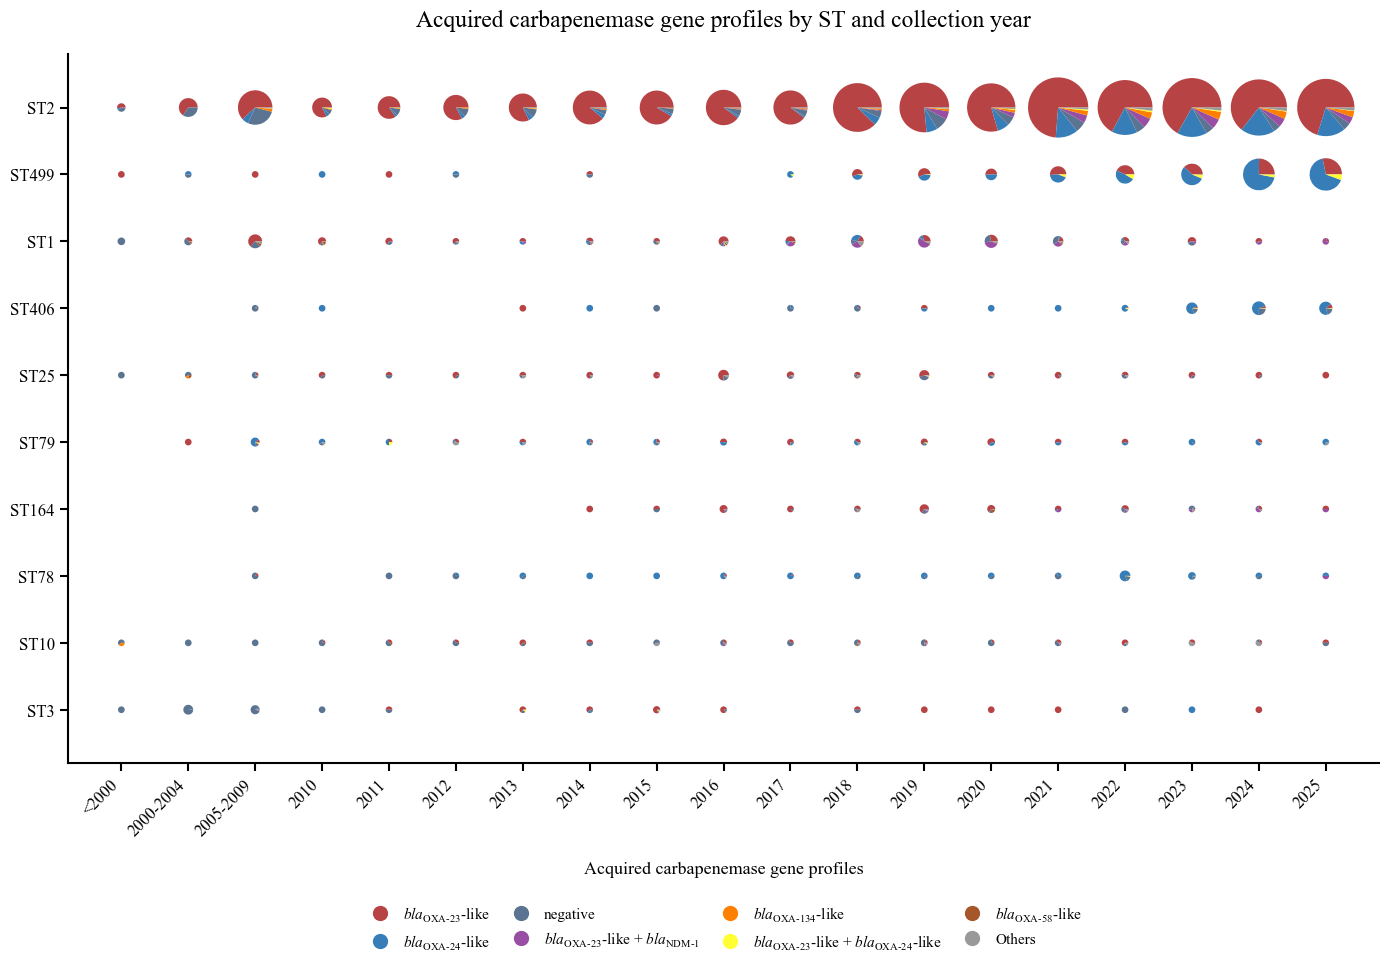

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 0. 全局字体设置与公式字体接管
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# ================= 核心配置 =================
# 强制数学公式（图例中的斜体和下标）也使用不加粗的 Times New Roman
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'         # 正体使用常规新罗马
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'  # 斜体使用常规新罗马斜体
# ================================================

# ==========================================
# 1. 数据读取与时间分箱 (Year Binning)
# ==========================================
meta_df = pd.read_csv(r'D:\A.baumannii\data\antibiotic_classes_matched_metadata.csv')
geno_df = pd.read_csv(r'D:\A.baumannii\data\carbapenem_matched_representatives.csv')

# 1.1 筛选 ST: 剔除 '-', 取前 10
valid_st = meta_df[(meta_df['ST'].notna()) & (meta_df['ST'].astype(str).str.strip() != '-')]
top10_st = valid_st['ST'].value_counts().nlargest(10).index.tolist()

# 1.2 处理 Year 列：定义时间分组逻辑
def assign_year_bin(y):
    try:
        y = int(float(y)) # 转化为整数
    except:
        return np.nan 
        
    if y < 2000:
        return '<2000'
    elif 2000 <= y <= 2004:
        return '2000-2004'
    elif 2005 <= y <= 2009:
        return '2005-2009'
    elif 2010 <= y <= 2025:
        return str(y)
    else:
        return np.nan

# 应用年份分组函数，生成新的一列 'year_bin'
meta_df['year_bin'] = meta_df['year'].apply(assign_year_bin)

# 定义严格的横轴显示顺序 (一共 19 个时间节点)
year_bins_order = ['<2000', '2000-2004', '2005-2009'] + [str(y) for y in range(2010, 2026)]

# 1.3 合并数据表
merged_df = pd.merge(meta_df[['Genome_ID', 'ST', 'year_bin']], 
                     geno_df[['Genome_ID', 'Genotype']], 
                     on='Genome_ID', how='inner')

# 1.4 根据 Top 10 ST 和 有效的年份区间截取子集
plot_df = merged_df[(merged_df['ST'].isin(top10_st)) & (merged_df['year_bin'].notna())].copy()

# 1.5 筛选 Genotype: 取子集中数量最多的前 7 种，剩下的归为 'Others'
top7_geno = plot_df['Genotype'].value_counts().nlargest(7).index.tolist()
plot_df['Plot_Label'] = plot_df['Genotype'].apply(lambda x: x if x in top7_geno else 'Others')

# 提取用于画图的所有分类名称
categories = top7_geno + ['Others'] if 'Others' not in top7_geno else top7_geno

# ==========================================
# 2. 数据透视与坐标映射
# ==========================================
# 按照 year_bin 替代原本的 country 进行分组
grouped = plot_df.groupby(['year_bin', 'ST', 'Plot_Label']).size().unstack(fill_value=0)
grouped['Total'] = grouped.sum(axis=1)
max_total = grouped['Total'].max()  

# 映射 Y 轴：ST 数量最多在最上
st_y_mapping = {st: i for i, st in enumerate(reversed(top10_st))}
# 映射 X 轴：严格按时间顺序排列
year_x_mapping = {y_bin: i for i, y_bin in enumerate(year_bins_order)}

# ==========================================
# 3. 颜色精准配置
# ==========================================
color_palette = ["#B84345", "#377EB8", "#5A7492", "#984EA3", "#FF7F00", "#FFFF33", "#A65628"]
color_dict = {}
c_idx = 0
for cat in categories:
    if cat == 'Negative':
        color_dict[cat] = '#E0E0E0'  
    elif cat == 'Others':
        color_dict[cat] = '#999999'  
    else:
        color_dict[cat] = color_palette[c_idx % len(color_palette)]
        c_idx += 1

# ==========================================
# 4. 绘制气泡饼图 (画布变宽以适应 19 个年份节点)
# ==========================================
fig, ax = plt.subplots(figsize=(15, 9))

base_radius = 0.45  

for (y_bin, st), row in grouped.iterrows():
    total_count = row['Total']
    if total_count == 0:
        continue
        
    x = year_x_mapping[y_bin]
    y = st_y_mapping[st]
    
    r = base_radius * np.sqrt(total_count / max_total)
    if r < 0.05: # 防止气泡过小看不见
        r = 0.05
    
    theta1 = 0
    for cat in categories:
        count = row.get(cat, 0)
        if count == 0:
            continue
        theta2 = theta1 + 360 * (count / total_count)
        wedge = Wedge(center=(x, y), r=r, theta1=theta1, theta2=theta2, 
                      facecolor=color_dict[cat], edgecolor='none')
        ax.add_patch(wedge)
        theta1 = theta2

# ==========================================
# 5. 坐标轴、刻度与边框美化
# ==========================================
ax.set_aspect('equal') 

# 配置 X 轴 (年份)
ax.set_xticks(range(len(year_bins_order)))
ax.set_xticklabels(year_bins_order, rotation=45, ha='right', fontsize=12)
ax.set_xlim(-0.8, len(year_bins_order) - 0.2)

# 配置 Y 轴 (ST)
yticklabels = [f"ST{st}" if not str(st).upper().startswith('ST') else str(st) for st in reversed(top10_st)]
ax.set_yticks(range(len(top10_st)))
ax.set_yticklabels(yticklabels, fontsize=12)
ax.set_ylim(-0.8, len(top10_st) - 0.2)

ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6, direction='out',
               bottom=True, left=True, top=False, right=False)

# ==========================================
# 6. 生成高级圆点图例与标题 (完美兼容新罗马与短横杠)
# ==========================================
ax.set_title('Acquired carbapenemase gene profiles by ST and collection year', fontsize=17, pad=20)

def format_genotype(name):
    if name in ['Negative', 'Others']:
        return name
        
    parts = name.split(' + ')
    formatted_parts = []
    
    for p in parts:
        if p.startswith('blaOXA-') or p.startswith('blaNDM-'):
            # 提取基因后缀（如 OXA-23）
            gene_suffix = p.replace('bla', '')
            # 使用标准的 \mathrm 和 \text{-} 完美兼容短横杠与 Times New Roman 正体
            suffix_math = gene_suffix.replace('-', r'}\text{-}\mathrm{')
            
            if p.startswith('blaOXA-'):
                formatted = rf'$\mathit{{bla}}_{{\mathrm{{{suffix_math}}}}}$' + '-like'
            else:
                formatted = rf'$\mathit{{bla}}_{{\mathrm{{{suffix_math}}}}}$'
            formatted_parts.append(formatted)
        else:
            formatted_parts.append(p)
            
    return ' + '.join(formatted_parts)

legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[cat], 
                          markersize=12, label=format_genotype(cat)) for cat in categories]

ax.text(0.5, -0.15, "Acquired carbapenemase gene profiles", ha='center', va='center', 
        transform=ax.transAxes, fontsize=13)

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.18), 
          ncol=4, frameon=False, fontsize=11, handletextpad=0.5, columnspacing=1.0)

plt.tight_layout()

# 保存高清图片
plt.savefig('ST and  year.png', dpi=600, bbox_inches='tight')
plt.show()


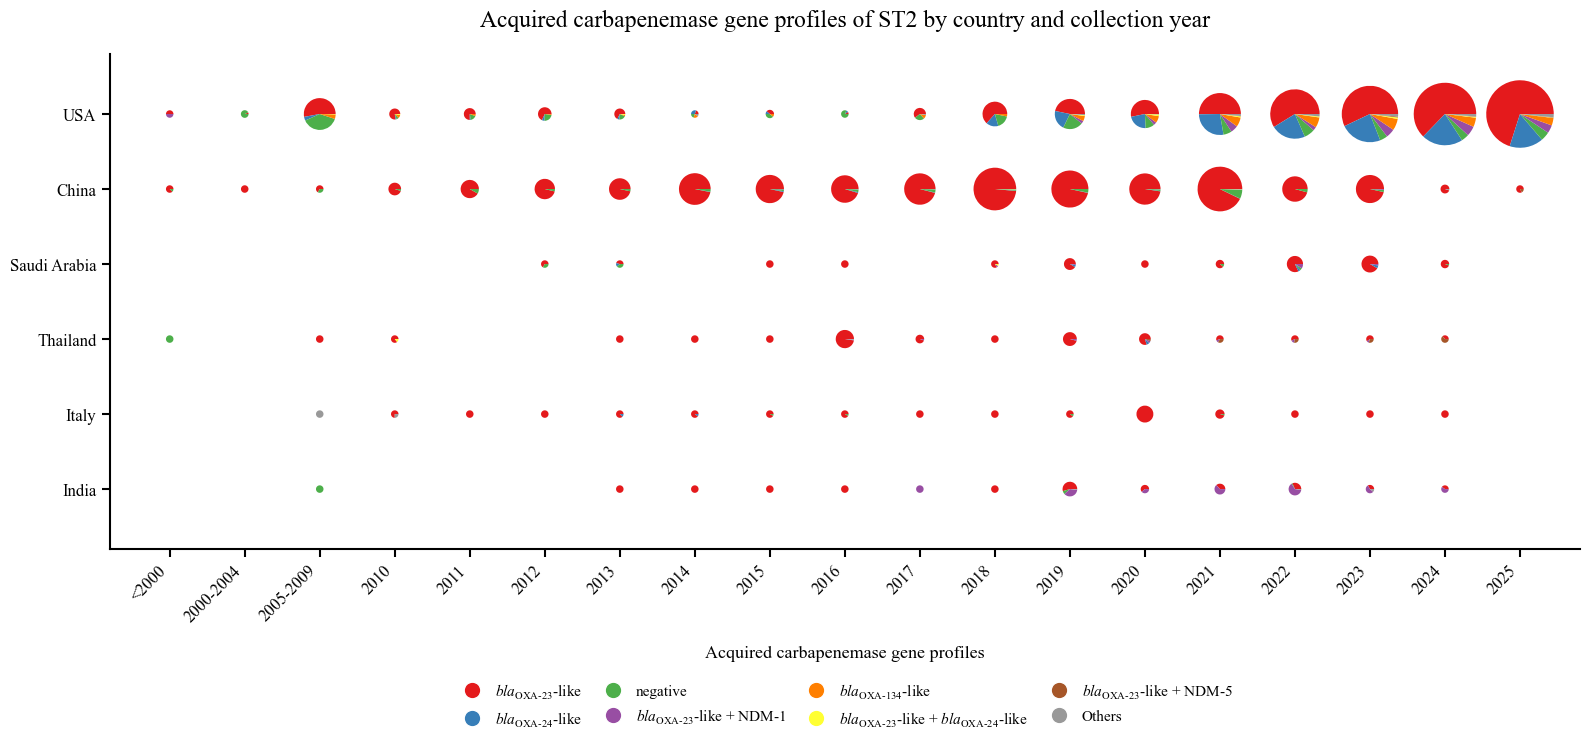

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 0. 全局字体设置
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# ================= 新增核心配置 =================
# 强制数学公式（图例中的斜体和下标）也使用不加粗的 Times New Roman
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'         # 正体使用常规新罗马
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'  # 斜体使用常规新罗马斜体
# ================================================

# ==========================================
# 1. 数据读取与 ST2 专属筛选
# ==========================================
meta_df = pd.read_csv(r'D:\python\敏感性分析\antibiotic_classes_matched_metadata.csv')
geno_df = pd.read_csv(r'D:\python\敏感性分析\碳青霉烯\carbapenem_matched_representatives.csv')

# 1.1 绝对锁定 ST2
meta_df = meta_df[(meta_df['ST'].notna()) & (meta_df['ST'].astype(str).str.strip() == '2')]

# 1.2 处理 Year 列：定义时间分组逻辑
def assign_year_bin(y):
    try:
        y = int(float(y)) # 转化为整数
    except:
        return np.nan 
        
    if y < 2000:
        return '<2000'
    elif 2000 <= y <= 2004:
        return '2000-2004'
    elif 2005 <= y <= 2009:
        return '2005-2009'
    elif 2010 <= y <= 2025:
        return str(y)
    else:
        return np.nan

meta_df['year_bin'] = meta_df['year'].apply(assign_year_bin)
year_bins_order = ['<2000', '2000-2004', '2005-2009'] + [str(y) for y in range(2010, 2026)]

# 1.3 筛选 Country: 提取 ST2 菌株数量最多的前 6 个国家，剔除 'others'
valid_country = meta_df[(meta_df['country'].notna()) & (meta_df['country'].astype(str).str.lower() != 'others')]
top6_country = valid_country['country'].value_counts().nlargest(6).index.tolist()

# 1.4 合并数据表
merged_df = pd.merge(meta_df[['Genome_ID', 'year_bin', 'country']], 
                     geno_df[['Genome_ID', 'Genotype']], 
                     on='Genome_ID', how='inner')

# 1.5 根据有效的时间和 Top6 国家截取子集
plot_df = merged_df[(merged_df['country'].isin(top6_country)) & (merged_df['year_bin'].notna())].copy()

# 1.6 筛选 Genotype: 取 ST2 子集中数量最多的前 7 种，剩下的归为 'Others'
top7_geno = plot_df['Genotype'].value_counts().nlargest(7).index.tolist()
plot_df['Plot_Label'] = plot_df['Genotype'].apply(lambda x: x if x in top7_geno else 'Others')

categories = top7_geno + ['Others'] if 'Others' not in top7_geno else top7_geno

# ==========================================
# 2. 数据透视与坐标映射
# ==========================================
# 按照 year_bin (X轴), country (Y轴) 分组统计
grouped = plot_df.groupby(['year_bin', 'country', 'Plot_Label']).size().unstack(fill_value=0)
grouped['Total'] = grouped.sum(axis=1)
max_total = grouped['Total'].max()  

# 映射 X 轴 (严格按年份时间轴排列)
year_x_mapping = {y_bin: i for i, y_bin in enumerate(year_bins_order)}
# 映射 Y 轴使用 top6_country
country_y_mapping = {country: i for i, country in enumerate(reversed(top6_country))}

# ==========================================
# 3. 颜色精准配置
# ==========================================
color_palette = ["#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00", "#FFFF33", "#A65628"]
color_dict = {}
c_idx = 0
for cat in categories:
    if cat == 'Negative':
        color_dict[cat] = '#E0E0E0'  
    elif cat == 'Others':
        color_dict[cat] = '#999999'  
    else:
        color_dict[cat] = color_palette[c_idx % len(color_palette)]
        c_idx += 1

# ==========================================
# 4. 绘制气泡饼图 (宽幅画布适应时间轴)
# ==========================================
# 6个国家纵向高度不需要8那么高，改为7比例更好看
fig, ax = plt.subplots(figsize=(16, 7))

base_radius = 0.45  # 防止重叠

for (y_bin, country), row in grouped.iterrows():
    total_count = row['Total']
    if total_count == 0:
        continue
        
    x = year_x_mapping[y_bin]
    y = country_y_mapping[country]
    
    r = base_radius * np.sqrt(total_count / max_total)
    if r < 0.05:  # 让数量极少的年份也能被看见
        r = 0.05
    
    theta1 = 0
    for cat in categories:
        count = row.get(cat, 0)
        if count == 0:
            continue
        theta2 = theta1 + 360 * (count / total_count)
        wedge = Wedge(center=(x, y), r=r, theta1=theta1, theta2=theta2, 
                      facecolor=color_dict[cat], edgecolor='none')
        ax.add_patch(wedge)
        theta1 = theta2

# ==========================================
# 5. 坐标轴、刻度与边框美化 
# ==========================================
ax.set_aspect('equal') 

# X 轴设置 (年份)
ax.set_xticks(range(len(year_bins_order)))
ax.set_xticklabels(year_bins_order, rotation=45, ha='right', fontsize=12)
ax.set_xlim(-0.8, len(year_bins_order) - 0.2)

# Y 轴设置 (国家)
ax.set_yticks(range(len(top6_country)))
ax.set_yticklabels(list(reversed(top6_country)), fontsize=12)
ax.set_ylim(-0.8, len(top6_country) - 0.2)

# L 型坐标轴
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6, direction='out',
               bottom=True, left=True, top=False, right=False)

# ==========================================
# 6. 生成高级圆点图例与标题
# ==========================================
ax.set_title('Acquired carbapenemase gene profiles of ST2 by country and collection year', fontsize=17, pad=20)

def format_genotype(name):
    if name in ['Negative', 'Others']:
        return name
        
    parts = name.split(' + ')
    formatted_parts = []
    
    for p in parts:
        if p.startswith('blaOXA-') or p.startswith('blaNDM-'):
            # 提取基因后缀（如 OXA-23）
            gene_suffix = p.replace('bla', '')
            # 【核心修改点】：使用标准的 \mathrm 和 \text{-} 完美兼容短横杠与 Times New Roman 正体
            suffix_math = gene_suffix.replace('-', r'}\text{-}\mathrm{')
            
            if p.startswith('blaOXA-'):
                formatted = rf'$\mathit{{bla}}_{{\mathrm{{{suffix_math}}}}}$' + '-like'
            else:
                formatted = rf'$\mathit{{bla}}_{{\mathrm{{{suffix_math}}}}}$'
            formatted_parts.append(formatted)
        else:
            formatted_parts.append(p)
            
    return ' + '.join(formatted_parts)

legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[cat], 
                          markersize=12, label=format_genotype(cat)) for cat in categories]

# 调整文字和图例在下方的位置
ax.text(0.5, -0.21, "Acquired carbapenemase gene profiles", ha='center', va='center', 
        transform=ax.transAxes, fontsize=13)

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.24), 
          ncol=4, frameon=False, fontsize=11, handletextpad=0.5, columnspacing=1.0)

plt.tight_layout()

# 保存高清图片
plt.savefig('ST2 country and year.png', dpi=600, bbox_inches='tight')
plt.show()
